In [20]:

from draughts import Color, AlphaBetaEngine, HubEngine
from draughts.boards.standard import Board
from draughts.benchmark import Benchmark
import tqdm

In [22]:
from pathlib import Path
import random

def is_late_game(board: Board):
    """Check if we're in endgame (few pieces)."""
    white_pieces = board.white_men | board.white_kings
    black_pieces = board.black_men | board.black_kings
    total_pieces = bin(white_pieces | black_pieces).count('1')
    return total_pieces <= 12

def has_many_choices(board: Board, threshold=5):
    """Positions with many legal moves are more interesting to learn."""
    return len(list(board.legal_moves)) >= threshold

with HubEngine(path=Path(r"E:\py-draughts\scan_engine\scan.exe"), depth_limit=11) as scanEngine:
    data = []
    sample_weights = []
    engine_vs_engine_games = 0
    high_choice_samples = 0
    late_game_samples = 0
    
    for game_idx in tqdm.tqdm(range(12000)):
        board = Board()
        
        game_depth = random.choice([9, 10, 11, 12, 13])
        scanEngine.depth_limit = game_depth
        
        engine_vs_engine = random.random() < 0.20
        if engine_vs_engine:
            engine_vs_engine_games += 1
        
        for _ in range(random.randint(0, 8)):
            moves = list(board.legal_moves)
            if not moves:
                break
            board.push(random.choice(moves))
        
        while not board.game_over:
            state = board.to_tensor()
            legal_moves = list(board.legal_moves)
            n_moves = len(legal_moves)
            
            # Skip positions with only 1 legal move (nothing to learn)
            if n_moves == 1:
                board.push(legal_moves[0])
                continue
            
            try:
                move, eval_score = scanEngine.get_best_move(board, with_evaluation=True)
            except RuntimeError as e:
                print("Engine error:", e)
                break
            
            if abs(eval_score) > 50:
                board.push(move)
                continue
            
            action = board.move_to_index(move)
            
            # Weight by decision complexity
            # In draughts, 15+ moves is genuinely complex, 20+ is rare
            weight = 1.0
            
            if n_moves >= 20:
                weight = 2.5
                high_choice_samples += 1
            elif n_moves >= 15:
                weight = 1.5
                high_choice_samples += 1
            
            # Endgame technique matters
            if is_late_game(board):
                weight = max(weight, 2.0)
                late_game_samples += 1

            data.append((state, action, eval_score))
            sample_weights.append(weight)
            
            if engine_vs_engine:
                board.push(move)
            elif random.random() < 0.03:
                board.push(random.choice(legal_moves))
            else:
                board.push(move)
        
        if (game_idx + 1) % 500 == 0:
            print(f"  Games: {game_idx+1}, Samples: {len(data)}, "
                  f"EvE: {engine_vs_engine_games}, HighChoice: {high_choice_samples}, Late: {late_game_samples}")

print(f"\n=== Data Collection Summary ===")
print(f"Total samples: {len(data)}")
print(f"Engine-vs-engine games: {engine_vs_engine_games}")
print(f"High-choice position samples: {high_choice_samples}")
print(f"Late-game samples: {late_game_samples}")

  4%|▍         | 500/12000 [04:50<1:11:04,  2.70it/s]

  Games: 500, Samples: 51673, EvE: 96, HighChoice: 6295, Late: 16301


  8%|▊         | 1000/12000 [09:20<1:25:02,  2.16it/s]

  Games: 1000, Samples: 103579, EvE: 200, HighChoice: 12917, Late: 32804


 12%|█▎        | 1500/12000 [13:52<1:50:25,  1.58it/s]

...

  Games: 11000, Samples: 1150338, EvE: 2163, HighChoice: 146084, Late: 376354


 96%|█████████▌| 11500/12000 [1:44:00<04:15,  1.95it/s]

  Games: 11500, Samples: 1203315, EvE: 2249, HighChoice: 153019, Late: 394242


100%|██████████| 12000/12000 [1:48:37<00:00,  1.84it/s]

  Games: 12000, Samples: 1256562, EvE: 2351, HighChoice: 159926, Late: 412586

=== Data Collection Summary ===
Total samples: 1256562
Engine-vs-engine games: 2351
High-choice position samples: 159926
Late-game samples: 412586


In [23]:
import pickle
with open("data2.pkl", "wb") as f:
    pickle.dump((data, sample_weights), f)
    

In [ ]:
import pickle 
with open("data2.pkl", "rb") as f:
    data, sample_weights = pickle.load(f)

In [24]:
# === Dataset Visualization & Analysis ===
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

print(f"Dataset size: {len(data):,} samples")
print(f"Total sample weights: {sum(sample_weights):,.1f}")
print(f"Average weight: {np.mean(sample_weights):.3f}")

Dataset size: 1,256,562 samples
Total sample weights: 1,717,491.0
Average weight: 1.367


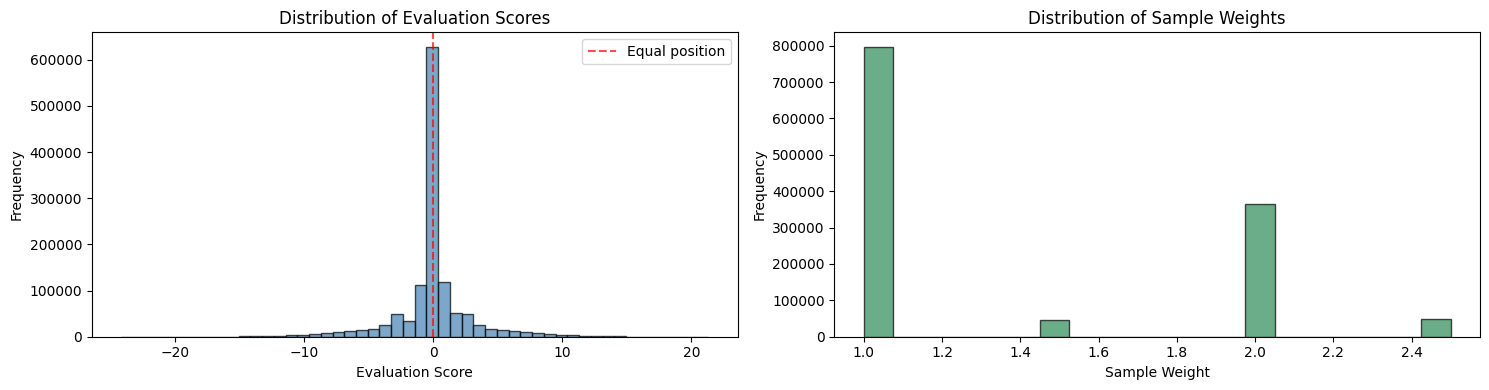

In [25]:
# Distribution of evaluation scores
eval_scores = [sample[2] for sample in data]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Eval score distribution
axes[0].hist(eval_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Evaluation Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Evaluation Scores')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Equal position')
axes[0].legend()

# Sample weights distribution
axes[1].hist(sample_weights, bins=20, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_xlabel('Sample Weight')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Sample Weights')


plt.tight_layout()
plt.show()

Tensor shape: (744946, 4, 50)


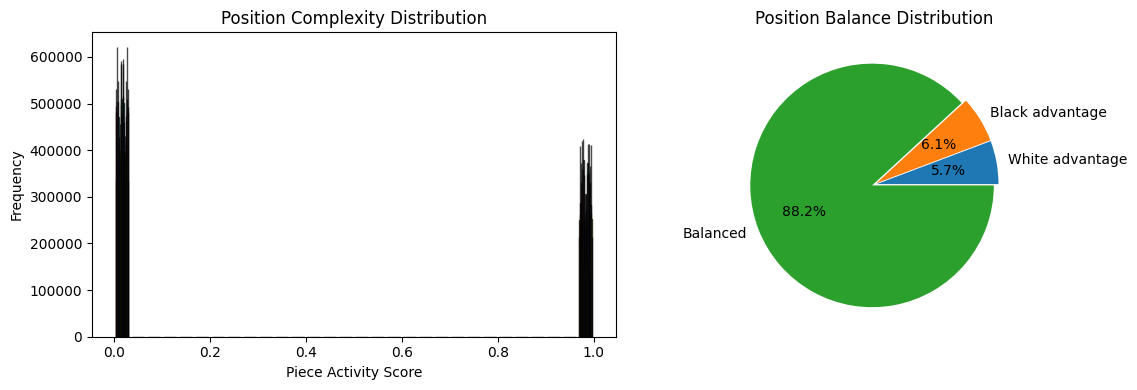


Position balance: White +5: 42,757 | Black +5: 45,504 | Balanced: 656,685


In [ ]:
# Analyze position diversity via tensor statistics
import numpy as np
tensors = np.array([sample[0] for sample in data])
print(f"Tensor shape: {tensors.shape}")

# Piece count distribution (sum of tensor values gives piece info)
piece_counts = tensors.sum(axis=(1, 2, 3)) if len(tensors.shape) == 4 else tensors.sum(axis=1)
    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(piece_counts, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Piece Activity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Position Complexity Distribution')

# Evaluate balance: positive evals vs negative vs neutral
positive = sum(1 for e in eval_scores if e > 5)
negative = sum(1 for e in eval_scores if e < -5)
neutral = len(eval_scores) - positive - negative

axes[1].pie([positive, negative, neutral], labels=['White advantage', 'Black advantage', 'Balanced'], 
            autopct='%1.1f%%',  explode=(0.02, 0.02, 0.02))
axes[1].set_title('Position Balance Distribution')

plt.tight_layout()
plt.show()

print(f"\nPosition balance: White +5: {positive:,} | Black +5: {negative:,} | Balanced: {neutral:,}")

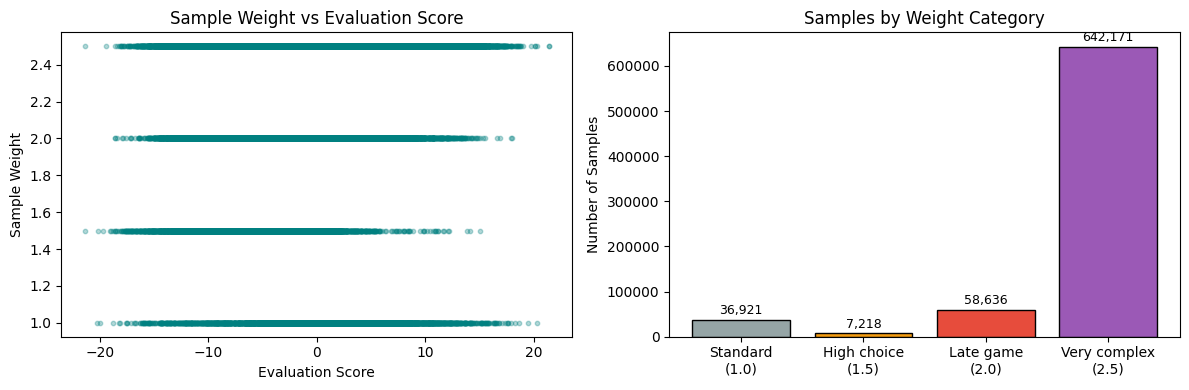

In [ ]:
# Correlation between sample weights and other features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weight vs eval score
axes[0].scatter(eval_scores, sample_weights, alpha=0.3, s=10, c='teal')
axes[0].set_xlabel('Evaluation Score')
axes[0].set_ylabel('Sample Weight')
axes[0].set_title('Sample Weight vs Evaluation Score')

# Weight distribution by category
weight_1_0 = sum(1 for w in sample_weights if w == 1.0)
weight_1_5 = sum(1 for w in sample_weights if w == 1.5)
weight_2_0 = sum(1 for w in sample_weights if w == 2.0)
weight_2_5 = sum(1 for w in sample_weights if w == 2.5)

categories = ['Standard\n(1.0)', 'High choice\n(1.5)', 'Late game\n(2.0)', 'Very complex\n(2.5)']
counts = [weight_1_0, weight_1_5, weight_2_0, weight_2_5]
colors = ['#95a5a6', '#f39c12', '#e74c3c', '#9b59b6']

axes[1].bar(categories, counts, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Samples by Weight Category')
for i, count in enumerate(counts):
    axes[1].text(i, count + max(counts)*0.02, f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Improved Data Generation Pipeline

The improved pipeline includes:
1. **Parallel game generation** using multiprocessing for faster data collection
2. **Stratified sampling** to ensure balanced representation of game phases
3. **Position deduplication** to avoid redundant training samples
4. **Progress tracking** with detailed statistics
5. **Incremental saving** to prevent data loss on interruption

In [ ]:
import hashlib
import pickle
import random
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Set, Optional
from datetime import datetime
import torch

@dataclass
class DataCollectionConfig:
    """Configuration for data collection."""
    num_games: int = 10000
    engine_path: Path = Path(r"E:\py-draughts\scan_engine\scan.exe")
    
    # Depth variation for position diversity
    min_depth: int = 9
    max_depth: int = 14
    
    # Sampling parameters
    engine_vs_engine_ratio: float = 0.25  # More EvE games for quality
    random_move_prob: float = 0.03
    max_random_opening_moves: int = 10
    
    # Position filtering
    min_legal_moves: int = 2
    max_eval_score: float = 40.0  # Tighter bound for balanced positions
    
    # Weighting thresholds
    high_choice_threshold: int = 12
    very_high_choice_threshold: int = 18
    late_game_piece_threshold: int = 10
    
    # Saving
    save_interval: int = 1000
    output_path: Path = Path("data_improved.pkl")
    checkpoint_path: Path = Path("data_checkpoint.pkl")

@dataclass 
class CollectionStats:
    """Track collection statistics."""
    total_games: int = 0
    total_samples: int = 0
    engine_vs_engine_games: int = 0
    high_choice_samples: int = 0
    late_game_samples: int = 0
    duplicates_skipped: int = 0
    filtered_by_eval: int = 0
    
    def summary(self) -> str:
        return (f"Games: {self.total_games:,} | Samples: {self.total_samples:,} | "
                f"EvE: {self.engine_vs_engine_games} | HighChoice: {self.high_choice_samples} | "
                f"LateGame: {self.late_game_samples} | Duplicates: {self.duplicates_skipped}")

def position_hash(board: Board) -> str:
    """Create a hash of the board position for deduplication."""
    state = (board.white_men, board.white_kings, board.black_men, board.black_kings, board.turn)
    return hashlib.md5(str(state).encode()).hexdigest()

def count_pieces(board: Board) -> int:
    """Count total pieces on the board."""
    all_pieces = board.white_men | board.white_kings | board.black_men | board.black_kings
    return bin(all_pieces).count('1')

def get_game_phase(board: Board) -> str:
    """Determine the game phase."""
    total_pieces = count_pieces(board)
    if total_pieces >= 20:
        return "opening"
    elif total_pieces >= 12:
        return "midgame"
    else:
        return "endgame"

def calculate_sample_weight(board: Board, n_moves: int, config: DataCollectionConfig) -> float:
    """Calculate sample weight based on position characteristics."""
    weight = 1.0
    
    # Decision complexity weighting
    if n_moves >= config.very_high_choice_threshold:
        weight = 3.0
    elif n_moves >= config.high_choice_threshold:
        weight = 2.0
    
    # Endgame positions are valuable for learning technique
    total_pieces = count_pieces(board)
    if total_pieces <= config.late_game_piece_threshold:
        weight = max(weight, 2.5)
    
    # King-involved positions (tactical)
    if board.white_kings or board.black_kings:
        weight *= 1.2
        
    return weight

print("Configuration and helper functions defined!")

In [ ]:
class ImprovedDataCollector:
    """Improved data collector with deduplication, stratification, and checkpointing."""
    
    def __init__(self, config: DataCollectionConfig):
        self.config = config
        self.stats = CollectionStats()
        self.data: List[Tuple] = []
        self.sample_weights: List[float] = []
        self.seen_positions: Set[str] = set()
        self.phase_counts = {"opening": 0, "midgame": 0, "endgame": 0}
        
    def save_checkpoint(self):
        """Save current progress to checkpoint file."""
        checkpoint = {
            "data": self.data,
            "sample_weights": self.sample_weights,
            "seen_positions": self.seen_positions,
            "stats": self.stats,
            "phase_counts": self.phase_counts,
            "timestamp": datetime.now().isoformat()
        }
        with open(self.config.checkpoint_path, "wb") as f:
            pickle.dump(checkpoint, f)
        print(f"  [Checkpoint saved: {len(self.data):,} samples]")
    
    def load_checkpoint(self) -> bool:
        """Load from checkpoint if available."""
        if self.config.checkpoint_path.exists():
            try:
                with open(self.config.checkpoint_path, "rb") as f:
                    checkpoint = pickle.load(f)
                self.data = checkpoint["data"]
                self.sample_weights = checkpoint["sample_weights"]
                self.seen_positions = checkpoint["seen_positions"]
                self.stats = checkpoint["stats"]
                self.phase_counts = checkpoint["phase_counts"]
                print(f"Loaded checkpoint from {checkpoint['timestamp']}: {len(self.data):,} samples")
                return True
            except Exception as e:
                print(f"Failed to load checkpoint: {e}")
        return False
    
    def add_sample(self, board: Board, action: int, eval_score: float) -> bool:
        """Add a sample with deduplication check."""
        pos_hash = position_hash(board)
        
        if pos_hash in self.seen_positions:
            self.stats.duplicates_skipped += 1
            return False
        
        self.seen_positions.add(pos_hash)
        
        state = board.to_tensor()
        n_moves = len(list(board.legal_moves))
        weight = calculate_sample_weight(board, n_moves, self.config)
        phase = get_game_phase(board)
        
        self.data.append((state, action, eval_score, phase))
        self.sample_weights.append(weight)
        self.phase_counts[phase] += 1
        self.stats.total_samples += 1
        
        if n_moves >= self.config.high_choice_threshold:
            self.stats.high_choice_samples += 1
        if count_pieces(board) <= self.config.late_game_piece_threshold:
            self.stats.late_game_samples += 1
            
        return True
    
    def play_game(self, engine) -> int:
        """Play a single game and collect samples."""
        board = Board()
        samples_this_game = 0
        
        # Vary engine depth per game
        engine.depth_limit = random.randint(self.config.min_depth, self.config.max_depth)
        
        # Determine if this is an engine-vs-engine game
        is_eve = random.random() < self.config.engine_vs_engine_ratio
        if is_eve:
            self.stats.engine_vs_engine_games += 1
        
        # Random opening moves for position diversity
        num_random_opening = random.randint(0, self.config.max_random_opening_moves)
        for _ in range(num_random_opening):
            moves = list(board.legal_moves)
            if not moves:
                break
            board.push(random.choice(moves))
        
        # Main game loop
        while not board.game_over:
            legal_moves = list(board.legal_moves)
            n_moves = len(legal_moves)
            
            if n_moves < self.config.min_legal_moves:
                if n_moves == 1:
                    board.push(legal_moves[0])
                continue
            
            try:
                move, eval_score = engine.get_best_move(board, with_evaluation=True)
            except RuntimeError as e:
                break
            
            # Filter out heavily unbalanced positions
            if abs(eval_score) > self.config.max_eval_score:
                self.stats.filtered_by_eval += 1
                board.push(move)
                continue
            
            action = board.move_to_index(move)
            if self.add_sample(board, action, eval_score):
                samples_this_game += 1
            
            # Move selection
            if is_eve:
                board.push(move)
            elif random.random() < self.config.random_move_prob:
                board.push(random.choice(legal_moves))
            else:
                board.push(move)
        
        self.stats.total_games += 1
        return samples_this_game
    
    def collect(self, resume: bool = True):
        """Run the full data collection."""
        if resume:
            self.load_checkpoint()
        
        start_game = self.stats.total_games
        
        with HubEngine(path=self.config.engine_path, depth_limit=11) as engine:
            pbar = tqdm.tqdm(range(start_game, self.config.num_games), 
                            initial=start_game, total=self.config.num_games)
            
            for game_idx in pbar:
                samples = self.play_game(engine)
                
                pbar.set_postfix({
                    "samples": f"{self.stats.total_samples:,}",
                    "dupes": self.stats.duplicates_skipped,
                    "filtered": self.stats.filtered_by_eval
                })
                
                # Periodic checkpoint
                if (game_idx + 1) % self.config.save_interval == 0:
                    self.save_checkpoint()
                    print(f"\n{self.stats.summary()}")
                    print(f"Phase distribution: {self.phase_counts}")
        
        # Final save
        self.save_final()
        
    def save_final(self):
        """Save final dataset."""
        # Convert to standard format (without phase info for training)
        training_data = [(s[0], s[1], s[2]) for s in self.data]
        
        with open(self.config.output_path, "wb") as f:
            pickle.dump((training_data, self.sample_weights), f)
        
        print(f"\n=== Final Data Collection Summary ===")
        print(self.stats.summary())
        print(f"Phase distribution: {self.phase_counts}")
        print(f"Unique positions: {len(self.seen_positions):,}")
        print(f"Saved to: {self.config.output_path}")

print("ImprovedDataCollector class defined!")

NameError: name 'DataCollectionConfig' is not defined

In [ ]:
# Example: Run the improved data collection
# Uncomment and adjust config as needed

# config = DataCollectionConfig(
#     num_games=10000,
#     engine_path=Path(r"E:\py-draughts\scan_engine\scan.exe"),
#     min_depth=9,
#     max_depth=14,
#     engine_vs_engine_ratio=0.25,
#     max_eval_score=40.0,
#     save_interval=500,
#     output_path=Path("data_improved.pkl")
# )

# collector = ImprovedDataCollector(config)
# collector.collect(resume=True)

print("To run improved collection, uncomment the code above and execute.")

## Data Augmentation Utilities

Additional utilities for augmenting and balancing the dataset after collection.

In [ ]:
def analyze_dataset_quality(data, sample_weights):
    """Comprehensive dataset quality analysis."""
    
    eval_scores = [s[2] for s in data]
    actions = [s[1] for s in data]
    
    print("=" * 60)
    print("DATASET QUALITY REPORT")
    print("=" * 60)
    
    # Basic stats
    print(f"\n📊 Basic Statistics:")
    print(f"   Total samples: {len(data):,}")
    print(f"   Unique actions: {len(set(actions)):,}")
    print(f"   Eval range: [{min(eval_scores):.1f}, {max(eval_scores):.1f}]")
    print(f"   Mean eval: {np.mean(eval_scores):.2f}")
    print(f"   Std eval: {np.std(eval_scores):.2f}")
    
    # Weight analysis
    print(f"\n⚖️ Sample Weights:")
    print(f"   Total effective samples: {sum(sample_weights):,.1f}")
    print(f"   Mean weight: {np.mean(sample_weights):.3f}")
    print(f"   High-weight samples (>1.5): {sum(1 for w in sample_weights if w > 1.5):,}")
    
    # Balance analysis
    white_adv = sum(1 for e in eval_scores if e > 5)
    black_adv = sum(1 for e in eval_scores if e < -5)
    balanced = len(eval_scores) - white_adv - black_adv
    
    print(f"\n⚖️ Position Balance:")
    print(f"   White advantage (>+5): {white_adv:,} ({100*white_adv/len(data):.1f}%)")
    print(f"   Black advantage (<-5): {black_adv:,} ({100*black_adv/len(data):.1f}%)")
    print(f"   Balanced positions: {balanced:,} ({100*balanced/len(data):.1f}%)")
    
    # Action distribution entropy (higher = more diverse)
    action_counts = Counter(actions)
    total = sum(action_counts.values())
    probs = [c/total for c in action_counts.values()]
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)
    max_entropy = np.log2(len(action_counts))
    
    print(f"\n🎯 Action Diversity:")
    print(f"   Entropy: {entropy:.2f} / {max_entropy:.2f} ({100*entropy/max_entropy:.1f}% of max)")
    print(f"   Most common action: {action_counts.most_common(1)[0]}")
    print(f"   Actions appearing once: {sum(1 for c in action_counts.values() if c == 1):,}")
    
    print("\n" + "=" * 60)
    
    return {
        "total": len(data),
        "entropy": entropy,
        "balance_ratio": balanced / len(data),
        "mean_weight": np.mean(sample_weights)
    }

# Analyze current dataset
if data:
    quality_metrics = analyze_dataset_quality(data, sample_weights)

DATASET QUALITY REPORT

📊 Basic Statistics:
   Total samples: 744,946
   Unique actions: 1,206
   Eval range: [-21.4, 21.4]
   Mean eval: -0.03
   Std eval: 3.23

⚖️ Sample Weights:
   Total effective samples: 1,770,447.5
   Mean weight: 2.377
   High-weight samples (>1.5): 700,807

⚖️ Position Balance:
   White advantage (>+5): 42,757 (5.7%)
   Black advantage (<-5): 45,504 (6.1%)
   Balanced positions: 656,685 (88.2%)

🎯 Action Diversity:
   Entropy: 7.68 / 10.24 (75.1% of max)
   Most common action: (463, 11287)
   Actions appearing once: 265



In [ ]:
def create_balanced_sampler(data, sample_weights, target_size: int = None):
    """Create indices for balanced sampling based on weights."""
    if target_size is None:
        target_size = len(data)
    
    # Normalize weights to probabilities
    total_weight = sum(sample_weights)
    probs = [w / total_weight for w in sample_weights]
    
    # Sample with replacement based on weights
    indices = np.random.choice(len(data), size=target_size, replace=True, p=probs)
    
    return indices

def undersample_majority(data, sample_weights, eval_threshold=5.0, target_ratio=0.4):
    """Undersample positions with extreme evaluations to balance the dataset."""
    balanced_data = []
    balanced_weights = []
    
    extreme_indices = []
    balanced_indices = []
    
    for i, (sample, weight) in enumerate(zip(data, sample_weights)):
        eval_score = sample[2]
        if abs(eval_score) <= eval_threshold:
            balanced_indices.append(i)
        else:
            extreme_indices.append(i)
    
    # Keep all balanced positions
    for i in balanced_indices:
        balanced_data.append(data[i])
        balanced_weights.append(sample_weights[i])
    
    # Undersample extreme positions
    target_extreme = int(len(balanced_indices) * target_ratio / (1 - target_ratio))
    if len(extreme_indices) > target_extreme:
        sampled_extreme = random.sample(extreme_indices, target_extreme)
    else:
        sampled_extreme = extreme_indices
    
    for i in sampled_extreme:
        balanced_data.append(data[i])
        balanced_weights.append(sample_weights[i])
    
    print(f"Original: {len(data):,} samples")
    print(f"Balanced positions: {len(balanced_indices):,}")
    print(f"Extreme positions kept: {len(sampled_extreme):,} / {len(extreme_indices):,}")
    print(f"Final dataset: {len(balanced_data):,} samples")
    
    return balanced_data, balanced_weights


Balancing utilities defined!


([<matplotlib.axis.XTick at 0x1c5c3615610>,
 [Text(0, 0, '463'),
  Text(1, 0, '668'),
  Text(2, 0, '2036'),
  Text(3, 0, '311'),
  Text(4, 0, '1831'),
  Text(5, 0, '516'),
  Text(6, 0, '2188'),
  Text(7, 0, '567'),
  Text(8, 0, '1932'),
  Text(9, 0, '1983'),
  Text(10, 0, '1627'),
  Text(11, 0, '1882'),
  Text(12, 0, '872'),
  Text(13, 0, '821'),
  Text(14, 0, '617'),
  Text(15, 0, '973'),
  Text(16, 0, '1526'),
  Text(17, 0, '669'),
  Text(18, 0, '260'),
  Text(19, 0, '1830'),
  Text(20, 0, '922'),
  Text(21, 0, '2239'),
  Text(22, 0, '1577'),
  Text(23, 0, '1678'),
  Text(24, 0, '1679'),
  Text(25, 0, '820'),
  Text(26, 0, '719'),
  Text(27, 0, '1780'),
  Text(28, 0, '2087'),
  Text(29, 0, '361')])

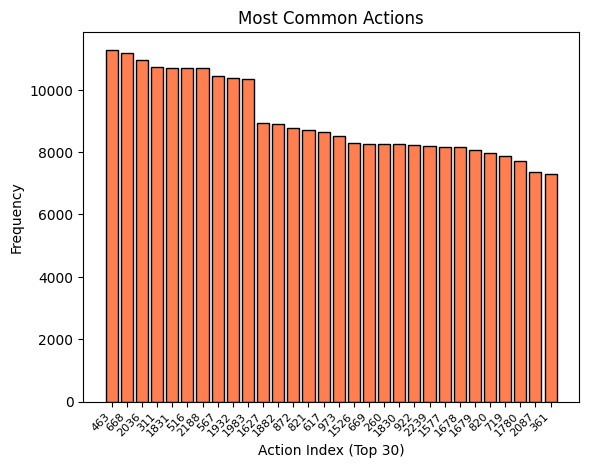

In [ ]:
# Actions distribution
actions = [sample[1] for sample in data]
action_counts = Counter(actions)
top_actions = action_counts.most_common(30)
plt.bar(range(len(top_actions)), [c for _, c in top_actions], color='coral', edgecolor='black')
plt.xlabel('Action Index (Top 30)')
plt.ylabel('Frequency')
plt.title('Most Common Actions')
plt.xticks(range(len(top_actions)), [str(a) for a, _ in top_actions], rotation=45, ha='right', fontsize=8)
